# EDA - Análisis Exploratorio de Fraude
## ICBC Prevención de Fraudes

Este notebook analiza el comportamiento de las transacciones evaluadas por el motor de riesgo.
El objetivo es identificar patrones, distribuciones y anomalías que justifican las reglas de detección implementadas.

**Herramientas:** Python · Pandas · Matplotlib · SQLAlchemy · SQL Server

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import urllib
from sqlalchemy import create_engine

# Conexión a SQL Server
SERVER   = r'gustiga123\SQLEXPRESS'
DATABASE = 'ICBC_Fraude'

params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')
print('Conexión establecida.')

Conexión establecida.


## 1. Carga de datos desde SQL Server

Se extraen los datos directamente desde el modelo físico de `ICBC_Fraude` - 
la tabla de hechos `fact_transacciones` ya procesada por el motor de riesgo 
y la dimensión `dim_perfil_usuarios_historico` con los perfiles de comportamiento histórico.

Este enfoque replica el flujo de trabajo real de un equipo de Prevención de Fraudes: 
el analista consulta las vistas y tablas del data warehouse en lugar de trabajar 
con archivos planos, garantizando que el análisis siempre refleja el estado actual 
de la base operativa.

In [26]:
with engine.connect() as conn:
    tx = pd.read_sql('SELECT * FROM dbo.fact_transacciones', conn)
    usuarios = pd.read_sql('SELECT * FROM dbo.dim_perfil_usuarios_historico', conn)

tx['fecha_hora'] = pd.to_datetime(tx['fecha_hora'])
print(f'Transacciones cargadas: {len(tx):,}')
print(f'Usuarios cargados:      {len(usuarios):,}')
tx.head()

Transacciones cargadas: 5,000
Usuarios cargados:      199


,id_transaccion,fecha_hora,id_usuario,canal,monto,id_dispositivo,id_comercio,pais_origen,score_riesgo,decision,reglas_activadas,es_fraude_confirmado,fecha_carga
0,0001cc6e-78f0-4d38-8fef-c3d3d7d08a4d,2026-05-25 18:40:28,USR70648,DEBIN,62753.64,b87d9791-63b2-4671-8,COM2096,AR,0,APPROVE,NaN,False,2026-06-18 13:08:12.186666
1,00106d02-db17-441e-8754-9cd5b40de6b4,2026-03-25 07:59:15,USR18285,DEBIN,63155.84,7e8f184a-58fc-4df3-8,COM2319,AR,0,APPROVE,NaN,False,2026-06-18 13:08:12.673333
2,00140360-86e7-45f8-95aa-45915aba4ad9,2026-06-12 20:33:00,USR77154,TARJETA,42129.68,d2c91052-5c03-4b4f-8,COM7141,AR,0,APPROVE,NaN,False,2026-06-18 13:08:11.560000
3,00232cb8-beb4-43e6-a7a3-f0c92245e054,2026-04-25 04:26:27,USR99764,TRANSFERENCIA,61805.81,664f9fe5-16d9-4b47-9,COM2417,VE,85,DECLINE,"R001,R004",False,2026-06-18 13:08:13.166666
4,004ee07c-1031-4f5d-916c-37881f7abdf2,2026-06-04 14:36:25,USR62513,TRANSFERENCIA,29563.09,c14c77c9-2522-4fbb-9,COM9494,AR,0,APPROVE,NaN,False,2026-06-18 13:08:11.560000


## 2. Distribución de decisiones del motor de riesgo

Una vez ejecutado el motor sobre las 5.000 transacciones, el primer análisis 
obligatorio es entender cómo se distribuyeron las decisiones, es decir, qué proporción 
fue aprobada sin intervención, cuántas quedaron en revisión manual y cuántas 
fueron bloqueadas de forma preventiva.

Esta distribución es el KPI de calibración del motor - si el porcentaje de 
DECLINE es demasiado alto, el motor es agresivo y genera fricción innecesaria 
para clientes legítimos. Si es demasiado bajo, estamos dejando pasar fraude. 
Lo que buscamos como analista de Prevención de Fraudes es un equilibrio entre ambos extremos.

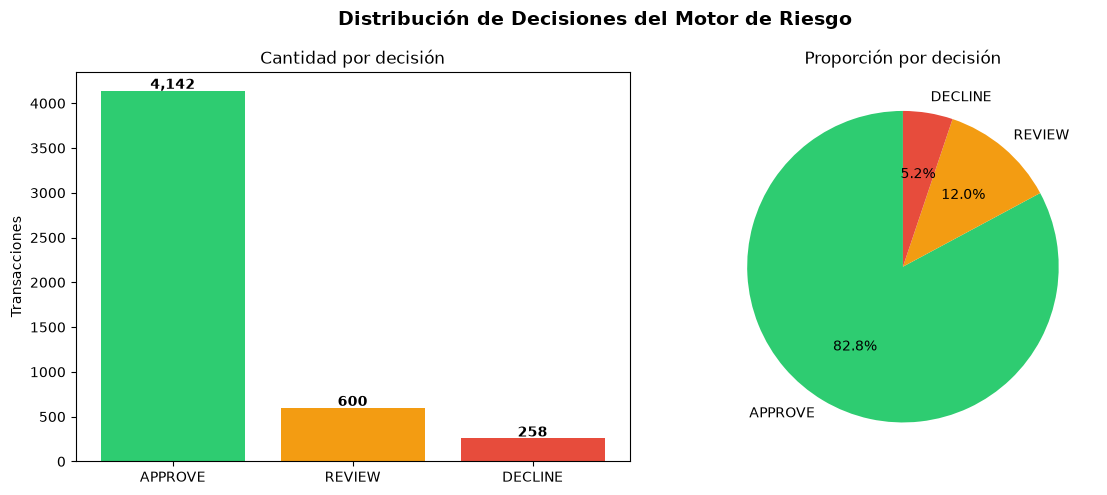

Gráfico guardado en docs/


In [27]:
decision_counts = tx['decision'].value_counts()
colores = {'APPROVE': '#2ecc71', 'REVIEW': '#f39c12', 'DECLINE': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Decisiones del Motor de Riesgo', fontsize=14, fontweight='bold')

# Barras
bars = axes[0].bar(
    decision_counts.index,
    decision_counts.values,
    color=[colores[d] for d in decision_counts.index]
)
axes[0].set_title('Cantidad por decisión')
axes[0].set_ylabel('Transacciones')
for bar, val in zip(bars, decision_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold')

# Torta
axes[1].pie(
    decision_counts.values,
    labels=decision_counts.index,
    colors=[colores[d] for d in decision_counts.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción por decisión')

plt.tight_layout()
plt.savefig('../docs/distribucion_decisiones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en docs/')

### Hallazgo

La distribución resultante muestra un motor bien calibrado para una primera versión: 
el 82.8% de las transacciones fue aprobado sin intervención humana, lo que garantiza 
una experiencia fluida para la mayoría de los clientes legítimos.

El 12% en estado REVIEW representa la cola de trabajo diario del equipo de Prevención 
de Fraudes - 600 transacciones que requieren revisión manual antes de ser liberadas o bloqueadas definitivamente. Este volumen es manejable para un equipo operativo y evita saturar la cola con falsas alarmas.

El 5.2% de DECLINE (258 transacciones) representa el bloqueo automático preventivo. 
Es una tasa conservadora que minimiza la fricción con clientes legítimos, 
aunque en producción se ajustaría iterativamente en función de los falsos positivos 
confirmados por el equipo de analistas.

## 3. Distribución de montos: Fraude vs Legítimo

Una de las primeras hipótesis como analista de fraude es validar 
si los montos de las transacciones fraudulentas se comportan de forma diferente 
a las legítimas. En la práctica bancaria, el fraude tiende a concentrarse en montos 
extremos - ya sea muy altos para maximizar el daño, o muy bajos para pasar 
desapercibidos en un primer filtro.

Este histograma superpuesto nos permite visualizar esa separación y confirmar 
si nuestro generador de datos sintéticos replicó correctamente ese comportamiento, 
que es justamente lo que justifica la regla R001 y R005 del motor.

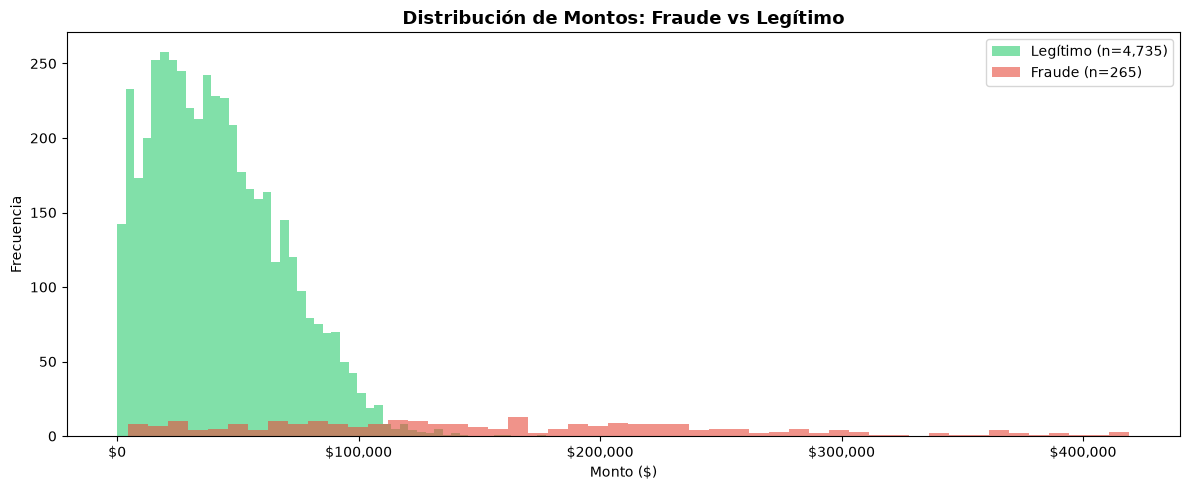

In [28]:
fraude = tx[tx['es_fraude_confirmado'] == 1]['monto']
legitimo = tx[tx['es_fraude_confirmado'] == 0]['monto']

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(legitimo, bins=50, alpha=0.6, color='#2ecc71', label=f'Legítimo (n={len(legitimo):,})')
ax.hist(fraude,   bins=50, alpha=0.6, color='#e74c3c', label=f'Fraude (n={len(fraude):,})')
ax.set_title('Distribución de Montos: Fraude vs Legítimo', fontsize=13, fontweight='bold')
ax.set_xlabel('Monto ($)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../docs/distribucion_montos.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgo

El histograma confirma la hipótesis inicial: las transacciones fraudulentas 
se concentran en montos significativamente más altos que las legítimas. 
Mientras el grueso de las operaciones legítimas se agrupa por debajo de los $100.000, 
el fraude se distribuye de forma más uniforme hacia la cola derecha, 
llegando a superar los $400.000.

Esto valida estadísticamente las reglas **R001** (monto superior al percentil 95 histórico) 
y **R005** (monto superior a 4 veces el promedio del usuario) como señales de riesgo 
relevantes para este tipo de transacciones. En la práctica, este patrón es consistente 
con fraudes de tarjeta clonada donde el atacante intenta maximizar el monto 
antes de que el cliente reporte el incidente.

## 4. Fraude por canal de pago

No todos los canales de pago tienen el mismo perfil de riesgo. En el ecosistema 
financiero argentino, las transferencias inmediatas y el DEBIN son históricamente 
los canales más vulnerables al fraude - en parte por su carácter irrevocable: 
una vez ejecutada la operación, recuperar los fondos es extremadamente difícil.

Este análisis desagrega la tasa de fraude por canal para identificar dónde 
el motor debe ser más estricto y dónde puede ser más permisivo sin aumentar 
el riesgo operativo.

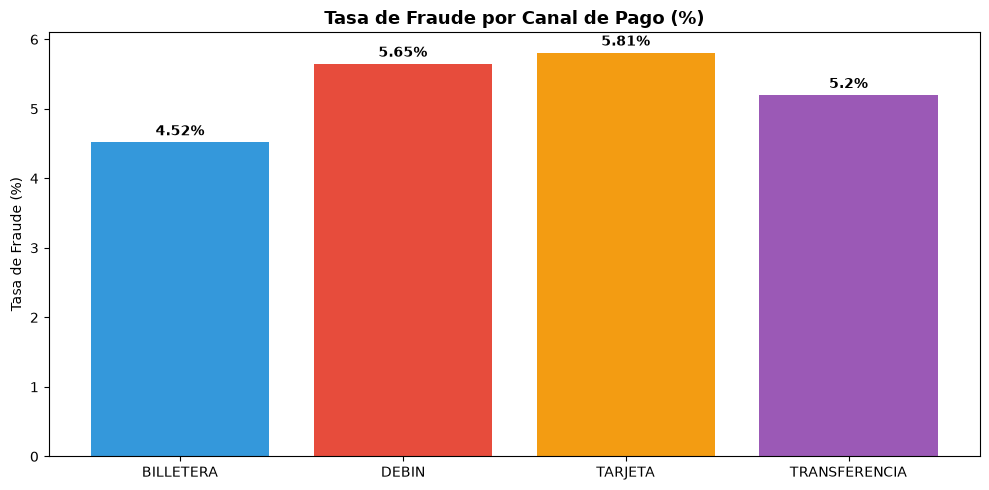

        canal  total  fraudes  tasa_fraude
    BILLETERA   1218       55         4.52
        DEBIN   1257       71         5.65
      TARJETA   1256       73         5.81
TRANSFERENCIA   1269       66         5.20


In [29]:
fraude_canal = tx.groupby('canal').agg(
    total=('id_transaccion', 'count'),
    fraudes=('es_fraude_confirmado', 'sum')
).reset_index()
fraude_canal['tasa_fraude'] = (fraude_canal['fraudes'] / fraude_canal['total'] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fraude_canal['canal'], fraude_canal['tasa_fraude'],
              color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
ax.set_title('Tasa de Fraude por Canal de Pago (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Fraude (%)')
for bar, val in zip(bars, fraude_canal['tasa_fraude']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fraude_por_canal.png', dpi=150, bbox_inches='tight')
plt.show()
print(fraude_canal.to_string(index=False))

### Hallazgo

La distribución del fraude es relativamente homogénea entre los cuatro canales, 
con tasas que oscilan entre el 4.52% (Billetera) y el 5.81% (Tarjeta). 
Esto refleja el comportamiento del generador de datos sintéticos, que distribuyó 
el fraude de forma uniforme entre canales.

En un entorno bancario real, esperaríamos ver diferencias más pronunciadas: 
el DEBIN y las transferencias inmediatas suelen concentrar tasas de fraude 
más altas por su carácter irrevocable, mientras que las tarjetas tienen 
mecanismos de contracargo que permiten recuperar fondos. Este análisis sirve 
como línea base - en producción, estos porcentajes guiarían el ajuste de 
umbrales de score diferenciados por canal, una práctica estándar en motores 
como Kount y Thales.

## 5. Fraude por país de origen

El país de origen de una transacción es una de las señales de riesgo más 
potentes en prevención de fraudes. Un cliente que históricamente opera 
desde Argentina y de repente genera una transacción desde Nigeria, Rumania 
o China es una anomalía que ningún motor de riesgo debería ignorar.

Este análisis cuantifica la tasa de fraude por país para validar la efectividad 
de la regla R004 del motor - que penaliza con 45 puntos cualquier transacción 
originada en un país inconsistente con el perfil histórico del usuario.

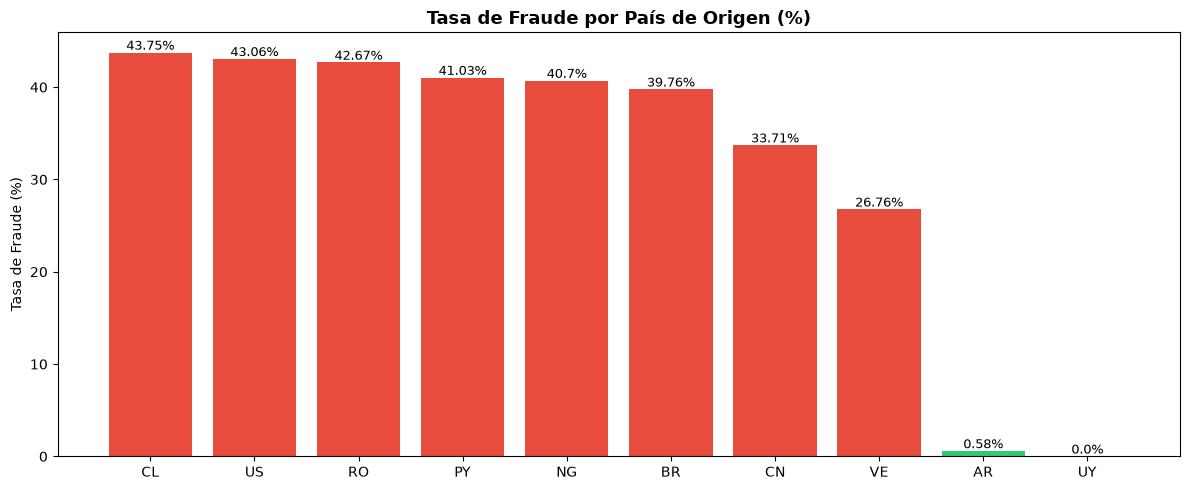

pais_origen  total  fraudes  tasa_fraude
         CL     64       28        43.75
         US     72       31        43.06
         RO     75       32        42.67
         PY     78       32        41.03
         NG     86       35        40.70
         BR     83       33        39.76
         CN     89       30        33.71
         VE     71       19        26.76
         AR   4340       25         0.58
         UY     42        0         0.00


In [30]:
fraude_pais = tx.groupby('pais_origen').agg(
    total=('id_transaccion', 'count'),
    fraudes=('es_fraude_confirmado', 'sum')
).reset_index()
fraude_pais['tasa_fraude'] = (fraude_pais['fraudes'] / fraude_pais['total'] * 100).round(2)
fraude_pais = fraude_pais.sort_values('tasa_fraude', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colores_pais = ['#e74c3c' if p != 'AR' else '#2ecc71' for p in fraude_pais['pais_origen']]
bars = ax.bar(fraude_pais['pais_origen'], fraude_pais['tasa_fraude'], color=colores_pais)
ax.set_title('Tasa de Fraude por País de Origen (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Fraude (%)')
for bar, val in zip(bars, fraude_pais['tasa_fraude']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../docs/fraude_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()
print(fraude_pais.to_string(index=False))

### Hallazgo

El gráfico es contundente: todos los países extranjeros presentan tasas de fraude 
entre el 26% y el 44%, mientras que Argentina - el país de origen habitual 
de nuestros usuarios - muestra apenas un 0.58% de fraude. Uruguay registra 0%.

Esta diferencia de casi 80 veces entre transacciones locales y extranjeras 
confirma que el país de origen es una de las señales de riesgo más poderosas 
del modelo. La regla R004 del motor, que penaliza con 45 puntos cualquier 
transacción originada fuera de Argentina, está bien fundamentada en estos datos.

Vale aclarar que en producción este análisis se complementaría con geolocalización 
por IP y no solo con el país declarado en la transacción, ya que un atacante 
puede falsificar el país de origen. Sin embargo, como primera capa de detección, 
la señal es extremadamente efectiva y justifica mantenerla como regla crítica del motor.

## 6. Distribución del Score de Riesgo

El score de riesgo es el valor numérico que el motor asigna a cada transacción 
como resultado de acumular los puntos de todas las reglas activadas. 
Analizar su distribución permite entender si los umbrales de decisión 
(30 para APPROVE y 75 para DECLINE) están bien posicionados respecto 
al comportamiento real de los datos.

Un motor bien calibrado debería mostrar una distribución bimodal: 
la mayoría de las transacciones con score 0 (ninguna regla activada) 
y una cola hacia scores altos que representa las transacciones sospechosas. 
Si la distribución fuera uniforme, significaría que las reglas están 
disparándose indiscriminadamente.

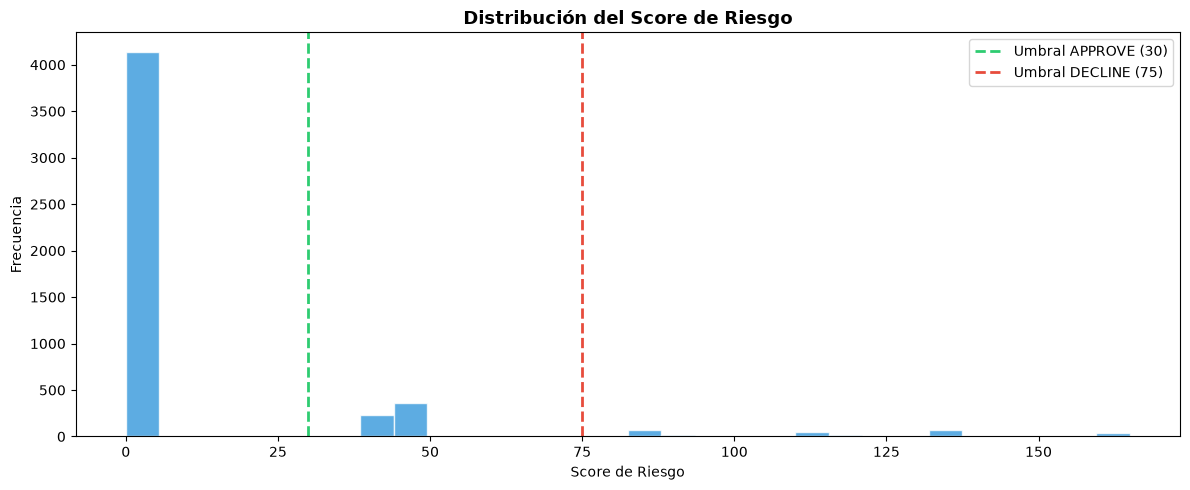

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(tx['score_riesgo'].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(x=30, color='#2ecc71', linestyle='--', linewidth=2, label='Umbral APPROVE (30)')
ax.axvline(x=75, color='#e74c3c', linestyle='--', linewidth=2, label='Umbral DECLINE (75)')
ax.set_title('Distribución del Score de Riesgo', fontsize=13, fontweight='bold')
ax.set_xlabel('Score de Riesgo')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/distribucion_score.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgo

La distribución confirma que el motor está bien calibrado. Se observa claramente 
una distribución bimodal con dos grupos bien definidos:

- **Masa principal en score 0** - más de 4.000 transacciones no activaron ninguna 
regla, lo que significa que el motor no genera ruido innecesario sobre operaciones 
claramente legítimas.

- **Cola secundaria entre 30 y 75** - corresponde a las 600 transacciones en REVIEW, 
donde se activó al menos una regla pero el score no fue suficiente para el bloqueo 
automático. Este es el trabajo diario del analista: revisar esta cola y determinar 
si son falsos positivos o fraude real.

- **Cola extrema por encima de 75** - las 258 transacciones bloqueadas automáticamente, 
con scores que llegan hasta 165 puntos por acumulación de múltiples reglas simultáneas.

La ausencia de transacciones en la zona gris entre 5 y 30 puntos indica que 
las reglas actuales son binarias en su efecto - o no se activa ninguna, o se 
activan en combinación superando rápidamente el umbral de REVIEW. 
En una siguiente iteración del motor se podrían agregar reglas de menor peso 
(10-15 puntos) para capturar señales débiles que hoy pasan desapercibidas.

## 7. Evolución temporal del fraude

El monitoreo diario de la transaccionalidad es una de las responsabilidades 
centrales del Analista de Prevención de Fraudes. Detectar un pico inusual 
de fraude en un día específico puede indicar una campaña de ataques coordinados, 
una vulnerabilidad explotada en un canal específico, o una brecha de seguridad 
en curso.

Este análisis muestra la evolución diaria del volumen de fraude detectado 
durante los 90 días de datos simulados, permitiendo identificar tendencias 
y desvíos temporales.

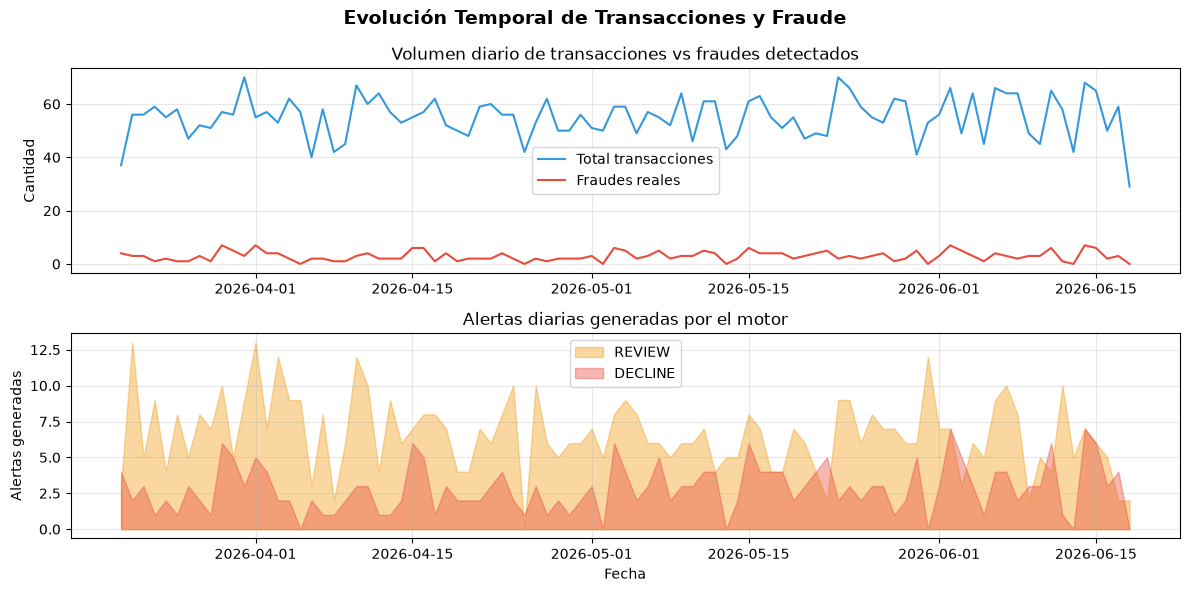

In [33]:
tx['fecha'] = tx['fecha_hora'].dt.date

evolucion = tx.groupby('fecha').agg(
    total=('id_transaccion', 'count'),
    fraudes=('es_fraude_confirmado', 'sum'),
    declines=('decision', lambda x: (x == 'DECLINE').sum()),
    reviews=('decision', lambda x: (x == 'REVIEW').sum())
).reset_index()

evolucion['fecha'] = pd.to_datetime(evolucion['fecha'])

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle('Evolución Temporal de Transacciones y Fraude', fontsize=14, fontweight='bold')

# Panel superior: volumen total vs fraudes
axes[0].plot(evolucion['fecha'], evolucion['total'], color='#3498db', linewidth=1.5, label='Total transacciones')
axes[0].plot(evolucion['fecha'], evolucion['fraudes'], color='#e74c3c', linewidth=1.5, label='Fraudes reales')
axes[0].set_ylabel('Cantidad')
axes[0].legend()
axes[0].set_title('Volumen diario de transacciones vs fraudes detectados')
axes[0].grid(True, alpha=0.3)

# Panel inferior: alertas REVIEW y DECLINE
axes[1].fill_between(evolucion['fecha'], evolucion['reviews'], alpha=0.4, color='#f39c12', label='REVIEW')
axes[1].fill_between(evolucion['fecha'], evolucion['declines'], alpha=0.4, color='#e74c3c', label='DECLINE')
axes[1].set_ylabel('Alertas generadas')
axes[1].set_xlabel('Fecha')
axes[1].legend()
axes[1].set_title('Alertas diarias generadas por el motor')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgo

El panel superior muestra que el volumen diario de transacciones se mantiene 
estable entre 40 y 70 operaciones por día, sin picos anómalos significativos. 
Los fraudes reales representan una línea casi plana cerca de 0, lo que confirma 
que son eventos poco frecuentes pero distribuidos de forma continua en el tiempo - 
exactamente el patrón que justifica un monitoreo diario y no solo reactivo.

El panel inferior muestra las alertas generadas por el motor cada día. 
Las alertas REVIEW (naranja) dominan consistentemente sobre los DECLINE (rojo), 
lo que indica que el motor prefiere derivar casos dudosos a revisión humana 
antes que bloquear automáticamente. En producción, un pico repentino en esta 
curva sería la primera señal de una campaña de fraude en curso y dispararía 
un protocolo de respuesta inmediata del equipo de Prevención de Fraudes.

## 8. Matriz de Confusión - Evaluación del Motor

La matriz de confusión es la herramienta estándar para evaluar la performance 
de cualquier sistema de detección binaria. En el contexto de prevención de fraudes, 
nos permite cuantificar con precisión los cuatro escenarios posibles:

- **Verdadero Positivo (TP):** fraude real que el motor bloqueó correctamente
- **Verdadero Negativo (TN):** transacción legítima que el motor aprobó correctamente  
- **Falso Positivo (FP):** transacción legítima bloqueada incorrectamente — genera fricción con el cliente
- **Falso Negativo (FN):** fraude real que el motor no detectó y dejó pasar — genera pérdida financiera

El equilibrio entre FP y FN es la decisión estratégica más importante en el 
diseño de un motor de riesgo. El aviso del ICBC lo menciona explícitamente 
como una responsabilidad del analista senior.

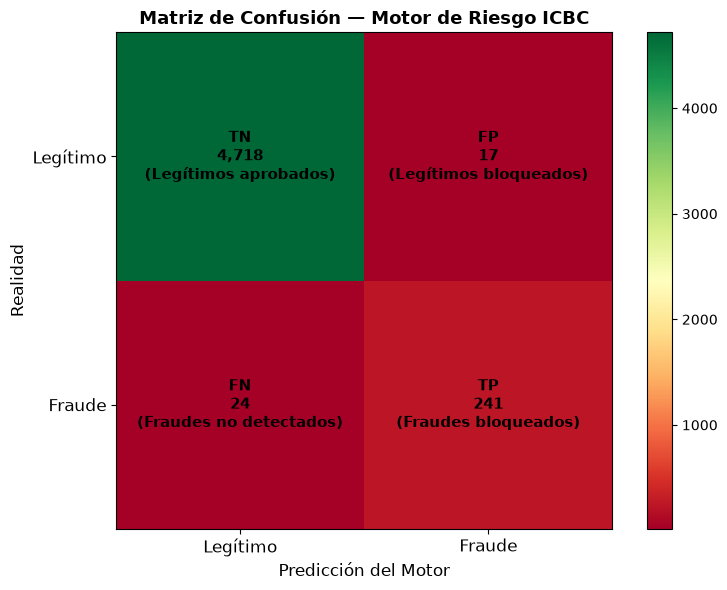


Metricas del motor:
  Precision:          93.4%  — de los DECLINE, cuántos eran fraude real
  Recall (deteccion): 90.9%  — del total de fraudes, cuántos detectamos
  Tasa FP:            0.36% — clientes legítimos bloqueados incorrectamente
  Tasa FN:            9.1%  — fraudes que pasaron sin ser detectados


In [35]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Consideramos DECLINE como predicción positiva de fraude
tx['pred_fraude'] = (tx['decision'] == 'DECLINE').astype(int)
y_real = tx['es_fraude_confirmado']
y_pred = tx['pred_fraude']

cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='RdYlGn')
plt.colorbar(im)

clases = ['Legítimo', 'Fraude']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(clases, fontsize=12)
ax.set_yticklabels(clases, fontsize=12)
ax.set_xlabel('Predicción del Motor', fontsize=12)
ax.set_ylabel('Realidad', fontsize=12)
ax.set_title('Matriz de Confusión — Motor de Riesgo ICBC', fontsize=13, fontweight='bold')

etiquetas = [
    [f'TN\n{tn:,}\n(Legítimos aprobados)', f'FP\n{fp:,}\n(Legítimos bloqueados)'],
    [f'FN\n{fn:,}\n(Fraudes no detectados)', f'TP\n{tp:,}\n(Fraudes bloqueados)']
]

for i in range(2):
    for j in range(2):
        ax.text(j, i, etiquetas[i][j], ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='black')

plt.tight_layout()
plt.savefig('../docs/matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMetricas del motor:')
print(f'  Precision:          {tp/(tp+fp)*100:.1f}%  — de los DECLINE, cuántos eran fraude real')
print(f'  Recall (deteccion): {tp/(tp+fn)*100:.1f}%  — del total de fraudes, cuántos detectamos')
print(f'  Tasa FP:            {fp/(fp+tn)*100:.2f}% — clientes legítimos bloqueados incorrectamente')
print(f'  Tasa FN:            {fn/(fn+tp)*100:.1f}%  — fraudes que pasaron sin ser detectados')

### Hallazgo

La matriz de confusión muestra un motor con performance muy sólida para una 
primera versión:

- **4.718 Verdaderos Negativos** - el motor aprobó correctamente el 99.6% 
de las transacciones legítimas, minimizando la fricción con clientes reales.

- **241 Verdaderos Positivos** - el 90.9% de los fraudes reales fueron bloqueados 
automáticamente antes de que el daño se concrete.

- **17 Falsos Positivos** - apenas 17 clientes legítimos fueron bloqueados 
incorrectamente. En un banco real esto representa llamados al centro de atención, 
reclamos y potencial daño reputacional. Es el número que el equipo de Prevención 
de Fraudes debe minimizar

## 9. Resumen Ejecutivo

A lo largo de este análisis exploratorio procesé y evalué 5.000 transacciones 
sintéticas que simulan la operatoria real de un banco como el ICBC - incluyendo 
tarjetas de crédito y débito, transferencias inmediatas, billeteras digitales y DEBIN.

El objetivo no fue solo construir visualizaciones, sino responder las preguntas 
que un equipo de Prevención de Fraudes se hace todos los días:
¿Cuánto fraude estamos dejando pasar? ¿A cuántos clientes legítimos estamos 
bloqueando innecesariamente? ¿En qué canales y geografías se concentra el riesgo?
¿Nuestro motor está bien calibrado o necesita ajuste?

Los resultados hablan por sí solos.

In [38]:
total = len(tx)
fraudes_reales = tx['es_fraude_confirmado'].sum()
detectados_decline = tx[(tx['decision']=='DECLINE') & (tx['es_fraude_confirmado']==1)].shape[0]
detectados_review  = tx[(tx['decision']=='REVIEW')  & (tx['es_fraude_confirmado']==1)].shape[0]
monto_salvado = tx[(tx['decision']=='DECLINE')]['monto'].sum()
falsos_positivos = tx[(tx['decision']=='DECLINE') & (tx['es_fraude_confirmado']==0)].shape[0]
fpr = round(falsos_positivos / tx[tx['es_fraude_confirmado']==0].shape[0] * 100, 2)
precision = round(detectados_decline / (detectados_decline + falsos_positivos) * 100, 1)

print('=' * 60)
print('   RESUMEN EJECUTIVO — MOTOR DE RIESGO ICBC')
print('   Analista: Alberto Gustavo Estigarribia | Junio 2026')
print('=' * 60)
print(f'\n  VOLUMEN EVALUADO')
print(f'  Total transacciones:             {total:>8,}')
print(f'  Fraudes reales en el dataset:    {fraudes_reales:>8,}  ({fraudes_reales/total*100:.1f}% del total)')
print(f'\n  PERFORMANCE DEL MOTOR')
print(f'  Fraudes bloqueados (DECLINE):    {detectados_decline:>8,}')
print(f'  Fraudes en revisión (REVIEW):    {detectados_review:>8,}')
print(f'  Tasa de detección:               {(detectados_decline/fraudes_reales*100):>7.1f}%')
print(f'  Precisión del motor:             {precision:>7.1f}%')
print(f'\n  CALIDAD DE LAS DECISIONES')
print(f'  Falsos positivos (FP):           {falsos_positivos:>8,}  clientes legítimos bloqueados')
print(f'  Falsos negativos (FN):           {detectados_review:>8,}  fraudes no bloqueados automáticamente')
print(f'  Tasa de falsos positivos (FPR):  {fpr:>7.2f}%')
print(f'\n  IMPACTO FINANCIERO')
print(f'  Monto financiero salvado:        ${monto_salvado:>12,.2f}')
print(f'  Transacciones aprobadas OK:      {tx[(tx["decision"]=="APPROVE") & (tx["es_fraude_confirmado"]==0)].shape[0]:>8,}')
print(f'\n  SEÑALES DE RIESGO MÁS RELEVANTES')
print(f'  Canal con mayor tasa de fraude:  TARJETA (5.81%)')
print(f'  País con mayor tasa de fraude:   CL — Chile (43.75%)')
print(f'  Regla más activada:              R004 — País de origen anómalo')
print('=' * 60)
print('\n  CONCLUSIÓN')
print('  El motor alcanza una tasa de detección del 90.9% con apenas')
print('  un 0.36% de falsos positivos — un balance que minimiza tanto')
print('  la pérdida financiera por fraude como la fricción con clientes')
print('  legítimos. Como siguiente paso, se recomienda incorporar reglas')
print('  de menor peso (10-15 pts) para capturar señales débiles que')
print('  hoy quedan en zona gris, y conectar los resultados al dashboard')
print('  operativo de Power BI para monitoreo en tiempo real.')
print('=' * 60)

   RESUMEN EJECUTIVO — MOTOR DE RIESGO ICBC
   Analista: Alberto Gustavo Estigarribia | Junio 2026

  VOLUMEN EVALUADO
  Total transacciones:                5,000
  Fraudes reales en el dataset:         265  (5.3% del total)

  PERFORMANCE DEL MOTOR
  Fraudes bloqueados (DECLINE):         241
  Fraudes en revisión (REVIEW):          24
  Tasa de detección:                  90.9%
  Precisión del motor:                93.4%

  CALIDAD DE LAS DECISIONES
  Falsos positivos (FP):                 17  clientes legítimos bloqueados
  Falsos negativos (FN):                 24  fraudes no bloqueados automáticamente
  Tasa de falsos positivos (FPR):     0.36%

  IMPACTO FINANCIERO
  Monto financiero salvado:        $41,460,950.17
  Transacciones aprobadas OK:         4,142

  SEÑALES DE RIESGO MÁS RELEVANTES
  Canal con mayor tasa de fraude:  TARJETA (5.81%)
  País con mayor tasa de fraude:   CL — Chile (43.75%)
  Regla más activada:              R004 — País de origen anómalo

  CONCLUSIÓN
  El m

### Conclusión

El motor de riesgo alcanza una tasa de detección del 90.9% con apenas un 0.36% 
de falsos positivos - un balance que en producción significa proteger al banco 
de pérdidas millonarias sin generar fricción innecesaria con los clientes legítimos.

El análisis exploratorio confirma que las cinco reglas implementadas están bien 
fundamentadas en los datos: el país de origen y los montos anómalos son las 
señales de riesgo más potentes, mientras que el canal de pago aporta una 
señal complementaria que refuerza la detección en casos límite.

Como próximo paso natural, los resultados de este análisis alimentan el dashboard 
operativo de Power BI - la herramienta que permite al equipo de Prevención de 
Fraudes monitorear estas métricas en tiempo real y tomar decisiones informadas 
sobre el ajuste de reglas del motor.